### Import Necessary Libraries

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

import warnings

warnings.filterwarnings(action="ignore")

### Step 1 -  Business Understanding

- Predict the MPG from the given dataset by considering all other depended features associate with it

### Step 2 - Data Collection

In [2]:
cars_data = pd.read_csv(filepath_or_buffer="Cars.csv")
cars_data

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
76,322,36.900000,50,169.598513,16.132947
77,238,19.197888,115,150.576579,37.923113
78,263,34.000000,50,151.598513,15.769625
79,295,19.833733,119,167.944460,39.423099


### Step 3 - Data Understanding

#### 3.1 Perform Initial Investigation on the data

In [3]:
cars_data.shape
## 81 record and 5 parameters
## or
## 81 observation and 5 features

(81, 5)

In [4]:
cars_data.isna().sum()

HP     0
MPG    0
VOL    0
SP     0
WT     0
dtype: int64

In [5]:
cars_data.describe()

,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


In [6]:
cars_data.dtypes

HP       int64
MPG    float64
VOL      int64
SP     float64
WT     float64
dtype: object

#### 3.2 Let's Check the Data Assumptions

The assumption tests are performed before building the model to verify whether the data is suitable for Linear Regression. If the assumptions are reasonably satisfied, the model is more likely to produce reliable and accurate predictions, although the actual performance can only be confirmed after training and evaluation.

**Assumption of Linear Regression**
![Assumption of Linear Regression](assets/asumption-of-linear-regression.png)

##### Test 1 : 3.2.1 Linearity Test

**📊 Linearity Assumption Test** 

**Definition:** \
Before training a Linear Regression model, we must verify that a linear relationship exists between each input feature and the target variable (MPG). This means the target should change at a constant rate as the input feature changes.

* Positive Linear Relationship: As the feature increases, MPG increases at a constant rate.
* Negative Linear Relationship: As the feature increases, MPG decreases at a constant rate.

How to Check it:
We use a Scatter Plot with a Trendline (sns.regplot).

* Pass: The data points scatter evenly along a straight line.
* Fail: The data points form a curve (like a "U" or "S" shape). If it fails, the linear regression model will make poor predictions.


**Expected Output**

![Expectation From Linearity Test](assets/expectation_from_linearity_test.png)



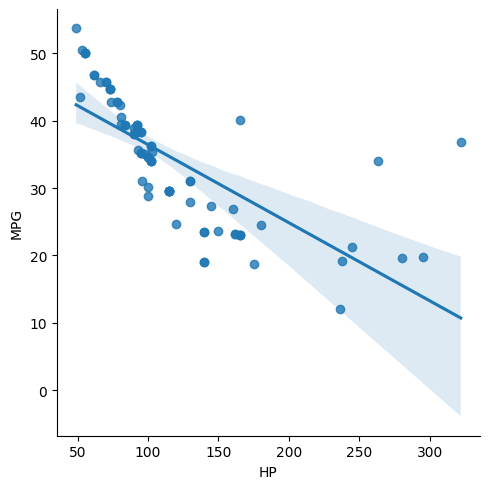

In [7]:
sns.lmplot(data=cars_data, x="HP", y="MPG")

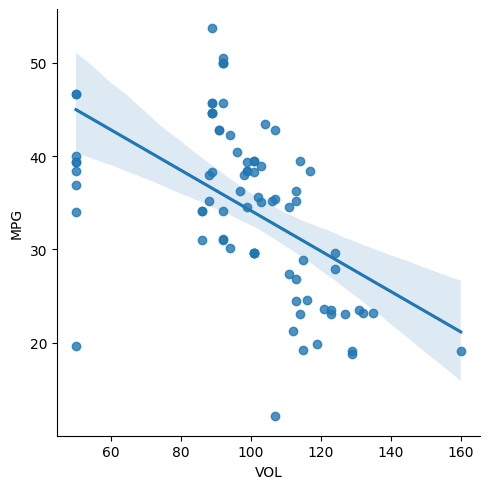

In [8]:
sns.lmplot(data=cars_data, x="VOL", y="MPG")

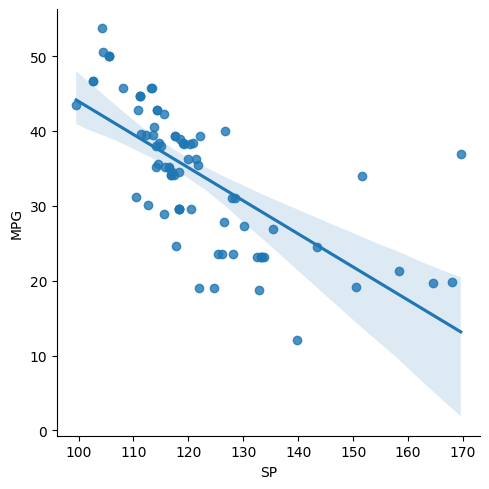

In [9]:
sns.lmplot(data=cars_data, x="SP", y="MPG")

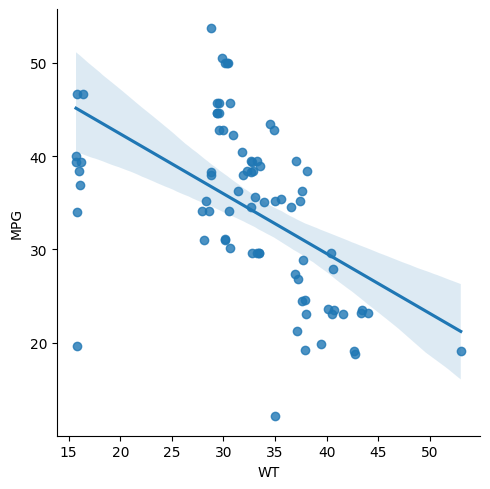

In [10]:
sns.lmplot(data=cars_data, x="WT", y="MPG")

##### Linearity Test Result
- Test got failed because all points are not falling into the linear line with respect to all input featues and output feature

##### Test 2 : 3.2.2 Normality Test

**Normality Test**

**Definition**

**The Normality Test is performed before building the Linear Regression model to check whether the numerical features are approximately normally distributed (bell-shaped). This helps us understand the data distribution and identify skewness or unusual values that may affect the model.**


**Why do we perform it?**

The purpose is to determine whether the data is suitable for Linear Regression and whether preprocessing is needed before training.

If the feature is approximately normal:

* ✅ The data is well distributed.
* ✅ The model is more likely to learn meaningful relationships.
* ✅ No transformation may be required.

If the feature is highly skewed:

* ⚠️ The feature may contain extreme values or outliers.
* ⚠️ You may need feature transformation (e.g., log transformation).
* ⚠️ Model performance can sometimes improve after preprocessing.


**Result Interpretation**

* **Pass:** The feature is approximately normally distributed, so no major preprocessing is required for this feature.
* **Fail:** The feature is not normally distributed. Consider investigating outliers or applying a suitable transformation before training the model.

**Expected Normality Test Output**

![Expected Normality Test Ouput](assets/expectation-from-normality-test.png)

**Normal Distribution**

![Normal Distribution](assets/nromal-distribution.png)



<Axes: xlabel='HP', ylabel='Count'>

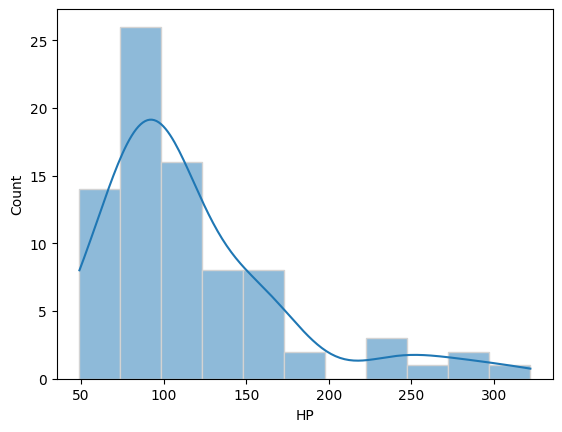

In [11]:
sns.histplot(data=cars_data, x="HP", kde=True, edgecolor="lightgray")

<Axes: xlabel='SP', ylabel='Count'>

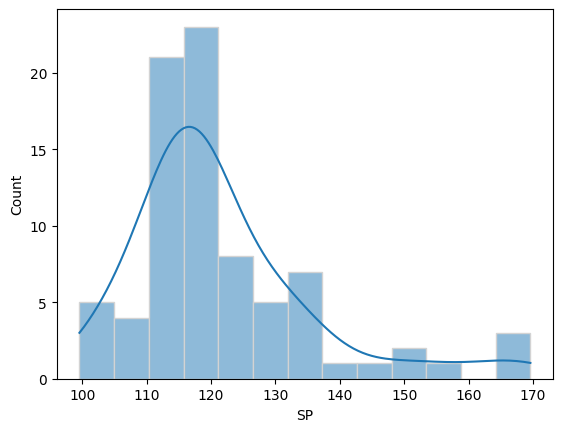

In [12]:
sns.histplot(data=cars_data, x="SP", kde=True, edgecolor="lightgray")

<Axes: xlabel='VOL', ylabel='Count'>

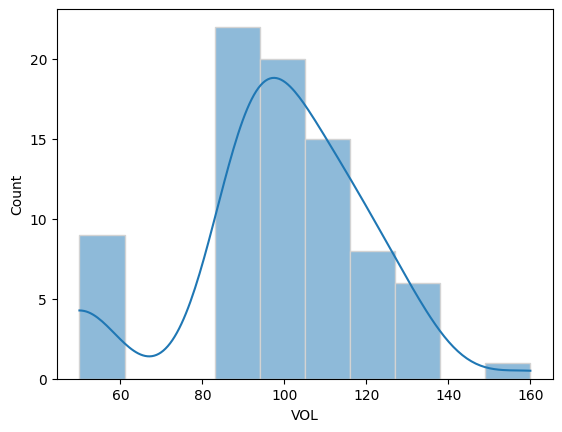

In [13]:
sns.histplot(data=cars_data, x="VOL", kde=True, edgecolor="lightgray")

<Axes: xlabel='WT', ylabel='Count'>

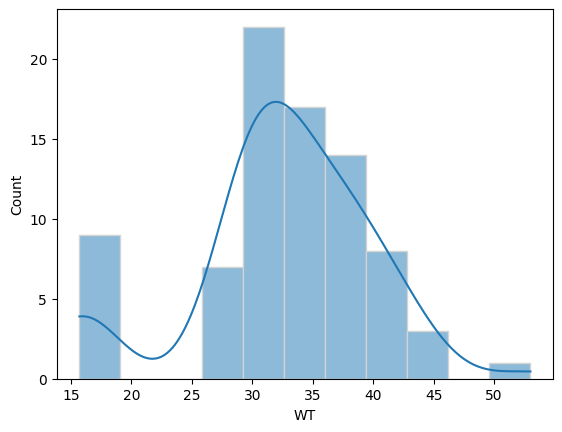

In [14]:
sns.histplot(data=cars_data, x="WT", kde=True, edgecolor="lightgray")

**Test 2**: Normality also failed, because none of them have the Normal Distribution

##### Test 2 : 3.2.3 Multi - Collinearity Test

The Multicollinearity Test is performed before building the Linear Regression model to ensure that the independent features are not highly correlated with each other, so that each feature contributes unique information and the model remains stable and interpretable.

In [15]:
corr_matrix = cars_data.corr()
corr_matrix

,HP,MPG,VOL,SP,WT
HP,1.000000,-0.725038,0.077459,0.973848,0.076513
MPG,-0.725038,1.000000,-0.529057,-0.687125,-0.526759
VOL,0.077459,-0.529057,1.000000,0.102170,0.999203
SP,0.973848,-0.687125,0.102170,1.000000,0.102439
WT,0.076513,-0.526759,0.999203,0.102439,1.000000


<Axes: >

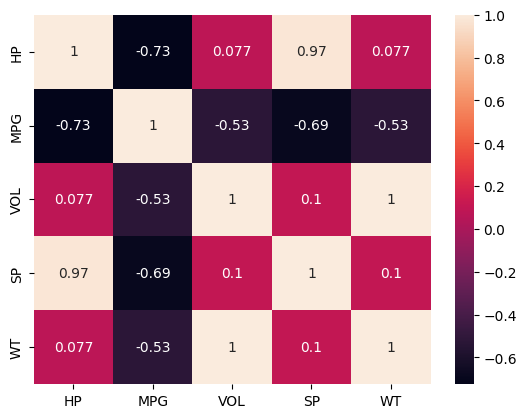

In [16]:
sns.heatmap(data=corr_matrix, annot=True, )

**Test 3 Result**: The dataset exhibits multicollinearity because HP–SP and VOL–WT are highly correlated, indicating redundant information among the independent features.

#### Test 4 - Auto Regression Passed

##### !Note : Test 5 - Homoscadacity and Test 6 - Zero Residual Mean --> Can be dome only after model is built, tranned and tested

---

### Step 4 - Data Preparationn

In [17]:
cars_data.head()

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149


##### There is nothing to prepare because all feeatues are numeric. [Feature engineering can be apllied]

In [19]:
x = cars_data[["HP", "VOL", "SP"]]
y = cars_data["MPG"]

In [20]:
x

,HP,VOL,SP
0,49,89,104.185353
1,55,92,105.461264
2,55,92,105.461264
3,70,92,113.461264
4,53,92,104.461264
...,...,...,...
76,322,50,169.598513
77,238,115,150.576579
78,263,50,151.598513
79,295,119,167.944460


In [21]:
y

0     53.700681
1     50.013401
2     50.013401
3     45.696322
4     50.504232
        ...    
76    36.900000
77    19.197888
78    34.000000
79    19.833733
80    12.101263
Name: MPG, Length: 81, dtype: float64

### Step 5: Model Building

In [18]:
linear_model = LinearRegression()

### Step 6 - Model Training

In [22]:
linear_model.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[-0.21,-0.2 , 0.4 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['HP','VOL','SP']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,29.92
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [23]:
linear_model.intercept_

np.float64(29.923389102475696)

In [24]:
linear_model.coef_

array([-0.20670477, -0.2016508 ,  0.40065935])

### Step 7 - Model Testing

In [28]:
y_predict = linear_model.predict(x)
y_predict

array([43.59076921, 42.25679373, 42.25679373, 42.36149697, 42.26954392,
       42.85590319, 42.25679373, 48.13220633, 48.13220633, 40.76616389,
       41.43447018, 47.94095346, 39.8656524 , 41.43447018, 41.67942553,
       41.43447018, 41.27332025, 47.94095346, 41.27332025, 38.01721633,
       38.66367435, 37.4600096 , 38.11461526, 39.42853629, 40.09224004,
       46.73897542, 35.69723723, 38.66367435, 38.09466788, 35.87282411,
       35.04066617, 37.18309295, 37.32689014, 34.69005715, 37.40254791,
       37.63924859, 39.28726919, 38.33839413, 38.33839413, 35.96910103,
       34.13369379, 35.28730823, 37.34958175, 38.25374535, 35.95926668,
       36.20871751, 34.23109277, 35.56225948, 36.95791342, 33.17920119,
       33.17920119, 33.17920119, 29.38875376, 27.38159079, 28.31041139,
       28.69213831, 35.78519493, 33.17920119, 35.43009046, 32.36990647,
       29.73729032, 28.87232774, 25.07081684, 26.38923335, 25.85376783,
       36.45743943, 25.91010746, 23.76768064, 24.4268889 , 20.12

### step 8 - Model Evaluation

In [30]:
error_difference = y - y_predict
error_difference

0     10.109912
1      7.756607
2      7.756607
3      3.334825
4      8.234688
        ...    
76    15.666857
77     1.330162
78     7.783144
79     7.596179
80    -3.491695
Name: MPG, Length: 81, dtype: float64

np.float64(34.42207572802469)

#### Let's now perform Test 5 -  homoscedasticity Test

<Axes: xlabel='HP', ylabel='MPG'>

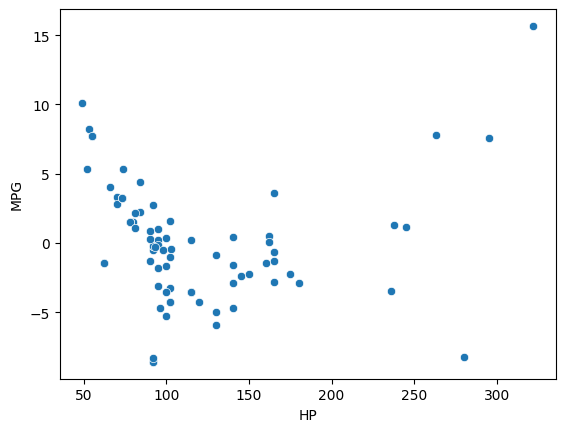

In [32]:
sns.scatterplot(x=cars_data['HP'], y=error_difference)

### Step 9 - Model Deployment

In [35]:
from pickle import dump, load

In [34]:
dump(obj=linear_model, file=open(file="Linear_Inteligence.pkl", mode="wb"))

In [37]:
linear_intel_pkl = load(file=open(file="Linear_Inteligence.pkl", mode="rb"))
linear_intel_pkl

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[-0.21,-0.2 , 0.4 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['HP','VOL','SP']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,29.92
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [38]:
linear_intel_pkl.predict(x)

array([43.59076921, 42.25679373, 42.25679373, 42.36149697, 42.26954392,
       42.85590319, 42.25679373, 48.13220633, 48.13220633, 40.76616389,
       41.43447018, 47.94095346, 39.8656524 , 41.43447018, 41.67942553,
       41.43447018, 41.27332025, 47.94095346, 41.27332025, 38.01721633,
       38.66367435, 37.4600096 , 38.11461526, 39.42853629, 40.09224004,
       46.73897542, 35.69723723, 38.66367435, 38.09466788, 35.87282411,
       35.04066617, 37.18309295, 37.32689014, 34.69005715, 37.40254791,
       37.63924859, 39.28726919, 38.33839413, 38.33839413, 35.96910103,
       34.13369379, 35.28730823, 37.34958175, 38.25374535, 35.95926668,
       36.20871751, 34.23109277, 35.56225948, 36.95791342, 33.17920119,
       33.17920119, 33.17920119, 29.38875376, 27.38159079, 28.31041139,
       28.69213831, 35.78519493, 33.17920119, 35.43009046, 32.36990647,
       29.73729032, 28.87232774, 25.07081684, 26.38923335, 25.85376783,
       36.45743943, 25.91010746, 23.76768064, 24.4268889 , 20.12